# Custom Backtest — Any Date Range

Fetches all data live from the internet. No local cache, no Kite login needed.

- **Stock OHLC** → yfinance (NSE data with `.NS` suffix)
- **NIFTY 50 index** → yfinance `^NSEI`
- **Point-in-time constituents** → hardcoded change history (no survivorship bias)

On each backtest day the strategy only picks from stocks that were **actually in the
NIFTY 50 on that date** — not the current composition.

## Set your dates here

In [26]:
START_DATE = '2023-04-01'   # YYYY-MM-DD  (earliest reliable data: 2021-04-01)
END_DATE   = '2026-04-07'   # YYYY-MM-DD

## Setup

In [27]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

LOOKBACK = 20     # sessions for rolling score
TOP_N    = 10     # stocks to buy each day
COST     = 0.0015 # 0.15% round-trip transaction cost per session

print('Ready.')

Ready.


## Point-in-Time NIFTY 50 Constituent History

The NIFTY 50 is rebalanced twice a year (March and September). Using the **current** composition
for a historical backtest introduces **survivorship bias** — you'd be trading stocks that only
entered the index *after* the test period, which is impossible in real life.

This cell embeds every known constituent change from **April 2021 to April 2026**.

In [28]:
# ── Baseline: NIFTY 50 composition as of 2021-04-01 ───────────────────────────
BASELINE_DATE = pd.Timestamp('2021-04-01')
BASELINE_COMPOSITION = [
    'ADANIPORTS', 'ASIANPAINT',  'AXISBANK',   'BAJAJ-AUTO',  'BAJFINANCE',
    'BAJAJFINSV', 'BHARTIARTL',  'BPCL',        'BRITANNIA',   'CIPLA',
    'COALINDIA',  'DIVISLAB',    'DRREDDY',     'EICHERMOT',   'GRASIM',
    'HCLTECH',    'HDFCBANK',    'HDFC',        'HDFCLIFE',    'HEROMOTOCO',
    'HINDALCO',   'HINDUNILVR',  'ICICIBANK',   'INDUSINDBK',  'INFY',
    'IOC',        'ITC',         'JSWSTEEL',    'KOTAKBANK',   'LT',
    'M&M',        'MARUTI',      'NESTLEIND',   'NTPC',        'ONGC',
    'POWERGRID',  'RELIANCE',    'SBILIFE',     'SBIN',        'SHREECEM',
    'SUNPHARMA',  'TCS',         'TATACONSUM',  'TATAMOTORS',  'TATASTEEL',
    'TECHM',      'TITAN',       'UPL',         'ULTRACEMCO',  'WIPRO',
]  # 50 stocks

# ── Rebalancing events: (effective_date, [added], [removed]) ─────────────────
CHANGE_EVENTS = [
    # 2022
    ('2022-03-31', ['APOLLOHOSP'],                      ['IOC']),
    ('2022-09-30', ['ADANIENT'],                        ['SHREECEM']),
    # 2023
    ('2023-07-13', ['LTIM'],                            ['HDFC']),   # HDFC merged into HDFCBANK
    # 2024
    ('2024-03-28', ['SHRIRAMFIN'],                      ['UPL']),
    ('2024-09-30', ['BEL', 'TRENT'],                    ['DIVISLAB', 'LTIM']),
    # 2025
    ('2025-03-28', ['JIOFIN'],                          ['BPCL']),
    ('2025-09-29', ['ETERNAL', 'INDIGO', 'MAXHEALTH'],  ['BRITANNIA', 'HEROMOTOCO', 'INDUSINDBK']),
    # Oct 2025: Tata Motors CV/PV demerger (effective Oct 1 2025).
    # TATAMOTORS (combined entity) exited the index.
    # TMPV (Tata Motors Passenger Vehicles) entered as a separate listed entity.
    # TATAMOTORS.NS and TMPV.NS are SEPARATE yfinance tickers — not the same series.
    ('2025-10-01', ['TMPV'],                            ['TATAMOTORS']),
]

# ── yfinance ticker map ───────────────────────────────────────────────────────
# Only for symbols where NSE symbol != yfinance base ticker.
# TATAMOTORS and TMPV are NOT aliased to each other — they are separate tickers.
YF_TICKER_MAP = {
    'HDFC':       'HDFC',        # merged into HDFCBANK Jul 2023 - likely 404 on yfinance
    'LTIM':       'LTIM',        # LTIMindtree (works from late 2022)
    'ETERNAL':    'ETERNAL',     # Zomato parent entity, listed Sep 2025
    'BAJAJ-AUTO': 'BAJAJ-AUTO',  # hyphen is fine in yfinance
    'M&M':        'M%26M',       # URL-encode & for yfinance
}

# ── Point-in-time constituent functions ───────────────────────────────────────
def get_constituents_on_date(dt):
    dt = pd.Timestamp(dt)
    comp = set(BASELINE_COMPOSITION)
    for date_str, added, removed in CHANGE_EVENTS:
        if dt >= pd.Timestamp(date_str):
            comp.update(added)
            comp.difference_update(removed)
    return comp

def get_full_universe(start, end):
    universe = set(BASELINE_COMPOSITION)
    for date_str, added, removed in CHANGE_EVENTS:
        if pd.Timestamp(date_str) <= pd.Timestamp(end):
            universe.update(added)
        if pd.Timestamp(date_str) < pd.Timestamp(start):
            universe.difference_update(removed)
    return sorted(universe)

# ── Sanity check ──
comp_apr21 = get_constituents_on_date('2021-04-01')
comp_oct25 = get_constituents_on_date('2025-10-02')  # after Tata demerger
comp_apr26 = get_constituents_on_date('2026-04-07')

print(f'Constituents on 2021-04-01: {len(comp_apr21)} stocks')
print(f'Constituents on 2025-10-02: {len(comp_oct25)} stocks  (post Tata demerger)')
print(f'Constituents on 2026-04-07: {len(comp_apr26)} stocks')
print()
print('Added 2021->2026:  ', sorted(comp_apr26 - comp_apr21))
print('Removed 2021->2026:', sorted(comp_apr21 - comp_apr26))
print()
assert 'TATAMOTORS' not in comp_apr26 and 'TMPV' in comp_apr26
assert 'TATAMOTORS' in comp_apr21 and 'TMPV' not in comp_apr21
print('Tata demerger check passed: TATAMOTORS in 2021, TMPV in 2026.')
print()
universe = get_full_universe(START_DATE, END_DATE)
print(f'Full universe for {START_DATE} to {END_DATE}: {len(universe)} distinct stocks')
print('Universe:', ', '.join(universe))


Constituents on 2021-04-01: 50 stocks
Constituents on 2025-10-02: 50 stocks  (post Tata demerger)
Constituents on 2026-04-07: 50 stocks

Added 2021->2026:   ['ADANIENT', 'APOLLOHOSP', 'BEL', 'ETERNAL', 'INDIGO', 'JIOFIN', 'MAXHEALTH', 'SHRIRAMFIN', 'TMPV', 'TRENT']
Removed 2021->2026: ['BPCL', 'BRITANNIA', 'DIVISLAB', 'HDFC', 'HEROMOTOCO', 'INDUSINDBK', 'IOC', 'SHREECEM', 'TATAMOTORS', 'UPL']

Tata demerger check passed: TATAMOTORS in 2021, TMPV in 2026.

Full universe for 2023-04-01 to 2026-04-07: 59 distinct stocks
Universe: ADANIENT, ADANIPORTS, APOLLOHOSP, ASIANPAINT, AXISBANK, BAJAJ-AUTO, BAJAJFINSV, BAJFINANCE, BEL, BHARTIARTL, BPCL, BRITANNIA, CIPLA, COALINDIA, DIVISLAB, DRREDDY, EICHERMOT, ETERNAL, GRASIM, HCLTECH, HDFC, HDFCBANK, HDFCLIFE, HEROMOTOCO, HINDALCO, HINDUNILVR, ICICIBANK, INDIGO, INDUSINDBK, INFY, ITC, JIOFIN, JSWSTEEL, KOTAKBANK, LT, LTIM, M&M, MARUTI, MAXHEALTH, NESTLEIND, NTPC, ONGC, POWERGRID, RELIANCE, SBILIFE, SBIN, SHRIRAMFIN, SUNPHARMA, TATACONSUM, TATAMOTO

## Step 1 — Map NSE symbols to yfinance tickers

In [29]:
def to_yf(nse_symbol):
    """Convert NSE symbol to yfinance ticker string."""
    mapped = YF_TICKER_MAP.get(nse_symbol, nse_symbol)
    return mapped + '.NS'

# Build universe ticker list
YF_TICKERS = [to_yf(s) for s in universe]

# Reverse map: yfinance ticker → NSE symbol (for display)
# When multiple NSE symbols map to the same yfinance ticker (TATAMOTORS/TMPV),
# we just keep one name — doesn't affect calculations.
YF_TO_NSE = {}
for sym in universe:
    yf_ticker = to_yf(sym)
    if yf_ticker not in YF_TO_NSE:
        YF_TO_NSE[yf_ticker] = sym

print(f'Unique yfinance tickers to fetch: {len(set(YF_TICKERS))}')
print('Tickers:', ', '.join(sorted(set(YF_TICKERS))))

Unique yfinance tickers to fetch: 59
Tickers: ADANIENT.NS, ADANIPORTS.NS, APOLLOHOSP.NS, ASIANPAINT.NS, AXISBANK.NS, BAJAJ-AUTO.NS, BAJAJFINSV.NS, BAJFINANCE.NS, BEL.NS, BHARTIARTL.NS, BPCL.NS, BRITANNIA.NS, CIPLA.NS, COALINDIA.NS, DIVISLAB.NS, DRREDDY.NS, EICHERMOT.NS, ETERNAL.NS, GRASIM.NS, HCLTECH.NS, HDFC.NS, HDFCBANK.NS, HDFCLIFE.NS, HEROMOTOCO.NS, HINDALCO.NS, HINDUNILVR.NS, ICICIBANK.NS, INDIGO.NS, INDUSINDBK.NS, INFY.NS, ITC.NS, JIOFIN.NS, JSWSTEEL.NS, KOTAKBANK.NS, LT.NS, LTIM.NS, M%26M.NS, MARUTI.NS, MAXHEALTH.NS, NESTLEIND.NS, NTPC.NS, ONGC.NS, POWERGRID.NS, RELIANCE.NS, SBILIFE.NS, SBIN.NS, SHRIRAMFIN.NS, SUNPHARMA.NS, TATACONSUM.NS, TATAMOTORS.NS, TATASTEEL.NS, TCS.NS, TECHM.NS, TITAN.NS, TMPV.NS, TRENT.NS, ULTRACEMCO.NS, UPL.NS, WIPRO.NS


## Step 2 — Fetch OHLC from yfinance

Downloads live data for **all stocks that were ever in NIFTY 50** across your date range.
Historical stocks (e.g. SHREECEM, HDFC) will have NaN after their removal/merger —
they are automatically excluded from rankings on those dates.

In [ ]:
# Fetch extra history before START_DATE for the 20-session warmup window
fetch_start = (pd.Timestamp(START_DATE) - pd.Timedelta(days=45)).strftime('%Y-%m-%d')
unique_tickers = sorted(set(YF_TICKERS))

print(f'Fetching OHLC for {len(unique_tickers)} tickers')
print(f'Period: {fetch_start} to {END_DATE}')
print('(This takes 60-120 seconds for the full universe)')

raw = yf.download(
    unique_tickers,
    start=fetch_start,
    end=END_DATE,
    progress=True,
    auto_adjust=True,
)

open_raw  = raw['Open'].copy()
close_raw = raw['Close'].copy()

# Rename columns from yfinance tickers back to NSE symbols
def strip_ns(ticker):
    return ticker.replace('.NS', '')

# Use the YF_TO_NSE map for renaming
open_raw.columns  = [YF_TO_NSE.get(c, strip_ns(c)) for c in open_raw.columns]
close_raw.columns = [YF_TO_NSE.get(c, strip_ns(c)) for c in close_raw.columns]

# TATAMOTORS and TMPV both mapped to TATAMOTORS.NS — rename the column
# so the point-in-time logic can match it by the correct constituent name
# We'll keep column as 'TATAMOTORS' and handle the TMPV alias in the backtest

# Report coverage
coverage = close_raw.notna().mean()
good = coverage[coverage > 0.1].index.tolist()
poor = coverage[coverage <= 0.1].index.tolist()

print(f'\nFetch complete.')
print(f'Date range in data: {close_raw.index[0].date()} to {close_raw.index[-1].date()}')
print(f'Symbols with >10% data coverage: {len(good)}')
if poor:
    print(f'Symbols with <10% coverage (will be treated as unavailable): {poor}')
    print('  These are likely historical stocks that were delisted or merged.')

Fetching OHLC for 59 tickers
Period: 2023-02-15 to 2026-04-07
(This takes 60-120 seconds for the full universe)


[******                12%                       ]  7 of 59 completed$HDFC.NS: possibly delisted; no timezone found
[******************    37%                       ]  22 of 59 completed$TATAMOTORS.NS: possibly delisted; no timezone found
[**********************49%                       ]  29 of 59 completed

KeyboardInterrupt: 

[**********************53%                       ]  31 of 59 completed

[**********************98%********************** ]  58 of 59 completed

## Step 3 — Compute overnight returns and scores

In [ ]:
# overnight_return[t] = open[t] / close[t-1] - 1
overnight_df = open_raw / close_raw.shift(1) - 1
overnight_df = overnight_df.iloc[1:]  # drop first row (NaN from shift)

# Rolling 20-session mean = score (min_periods=20 means no partial windows)
scores_df = overnight_df.rolling(window=LOOKBACK, min_periods=LOOKBACK).mean()

# Determine effective backtest range
first_score_date = scores_df.dropna(how='all').index[0]
eff_start = max(pd.Timestamp(START_DATE), first_score_date)
eff_end   = min(pd.Timestamp(END_DATE),   overnight_df.index[-1])
n_sessions = ((overnight_df.index >= eff_start) & (overnight_df.index <= eff_end)).sum()

print(f'Overnight returns computed for {len(overnight_df.columns)} symbols.')
print(f'First valid score date: {first_score_date.date()}')
print(f'Effective backtest:     {eff_start.date()} to {eff_end.date()} ({n_sessions} sessions)')

if n_sessions == 0:
    print('\nERROR: No sessions in range. Increase the date range or check START_DATE.')

Overnight returns computed for 61 symbols.
First valid score date: 2021-03-16
Effective backtest:     2021-04-01 to 2026-04-06 (1238 sessions)


## Step 4 — Run backtest (point-in-time constituents)

On each date `t`, the strategy:
1. Looks up which 50 stocks were **actually in the NIFTY 50 on date `t`**
2. Filters to those with data available (excludes delisted / not-yet-listed stocks)
3. Ranks by rolling 20-session overnight return score from date `t-1`
4. Buys the top 10 (score from yesterday, return from today)

In [ ]:
# resolve_col: maps a constituent NSE symbol to the DataFrame column name.
# No TATAMOTORS/TMPV alias needed — they are separate tickers with separate columns.
def resolve_col(sym, available_cols):
    if sym in available_cols:
        return sym
    # M&M was URL-encoded when fetching
    fallback = {'M&M': 'M%26M'}
    return fallback.get(sym, sym)

def run_strategy(mode='top'):
    """mode: 'top' (buy best-scoring) or 'bottom' (buy worst-scoring)"""
    test_idx = overnight_df.index[
        (overnight_df.index >= eff_start) & (overnight_df.index <= eff_end)
    ]
    out = {}
    available_cols = set(overnight_df.columns)

    for dt in test_idx:
        # --- 1. Score from the previous session (no lookahead) ---
        prev = scores_df.index[scores_df.index < dt]
        if prev.empty:
            continue
        score_row = scores_df.loc[prev[-1]]

        # --- 2. Point-in-time constituents for this date ---
        pit_syms = get_constituents_on_date(dt)

        # Resolve to column names (handles TATAMOTORS/TMPV alias)
        pit_cols = set()
        for sym in pit_syms:
            col = resolve_col(sym, available_cols)
            if col in available_cols:
                pit_cols.add(col)

        # --- 3. Intersect: must have score AND return AND be in today's index ---
        score_valid  = score_row[score_row.notna()].index
        return_valid = overnight_df.loc[dt].dropna().index
        eligible     = pit_cols & set(score_valid) & set(return_valid)

        if len(eligible) < TOP_N:
            continue

        eligible = list(eligible)
        if mode == 'top':
            picks = score_row[eligible].nlargest(TOP_N).index
        else:
            picks = score_row[eligible].nsmallest(TOP_N).index

        out[dt] = overnight_df.loc[dt, picks].mean() - COST

    label = 'Top-10 Strategy' if mode == 'top' else 'Bottom-10'
    return pd.Series(out, name=label)


def run_benchmark():
    """Equal-weight all point-in-time constituents (net of costs)."""
    test_idx = overnight_df.index[
        (overnight_df.index >= eff_start) & (overnight_df.index <= eff_end)
    ]
    out = {}
    available_cols = set(overnight_df.columns)

    for dt in test_idx:
        pit_syms = get_constituents_on_date(dt)
        pit_cols = [resolve_col(s, available_cols) for s in pit_syms
                    if resolve_col(s, available_cols) in available_cols]
        ret_row  = overnight_df.loc[dt, pit_cols].dropna()
        if len(ret_row) > 0:
            out[dt] = ret_row.mean() - COST

    return pd.Series(out, name='Equal-weight (PIT)')


print('Running backtest with point-in-time constituents...')
ret   = run_strategy('top')
bot   = run_strategy('bottom')
bench = run_benchmark()
print(f'Done. {len(ret)} sessions (top-10 strategy).')

Running backtest with point-in-time constituents...
Done. 1238 sessions (top-10 strategy).


## Results Summary

In [ ]:
def summarise(s, label=None):
    s = s.dropna()
    if len(s) == 0:
        print('  No data.')
        return
    label = label or s.name
    n_cal  = (s.index[-1] - s.index[0]).days
    total  = float((1 + s).prod() - 1)
    ann    = (1 + total) ** (365.25 / max(n_cal, 1)) - 1 if n_cal >= 20 else float('nan')
    sharpe = s.mean() / s.std() * np.sqrt(250) if s.std() > 0 else float('nan')
    cum    = (1 + s).cumprod()
    mdd    = float((cum / cum.cummax() - 1).min())
    wr     = float((s > 0).mean())

    print(f'  Period:        {s.index[0].date()}  to  {s.index[-1].date()}  ({len(s)} sessions)')
    print(f'  Total return:  {total:+.2%}')
    if not np.isnan(ann):
        print(f'  XIRR (ann.):   {ann:+.2%}')
    if not np.isnan(sharpe):
        print(f'  Sharpe ratio:  {sharpe:.2f}')
    print(f'  Max drawdown:  {mdd:.2%}')
    print(f'  Win rate:      {wr:.1%}  ({int(wr * len(s))}/{len(s)} sessions positive)')
    if (s > 0).any():  print(f'  Mean win:      {s[s > 0].mean():+.3%} per session')
    if (s <= 0).any(): print(f'  Mean loss:     {s[s <= 0].mean():+.3%} per session')
    print()
    print(f'  Rs 2,00,000 -> Rs {200_000 * (1 + total):>9,.0f}   (gain Rs {200_000 * total:>+8,.0f})')
    print(f'  Rs 4,00,000 -> Rs {400_000 * (1 + total):>9,.0f}   (gain Rs {400_000 * total:>+8,.0f})')


print('=' * 60)
print('  TOP-10 STRATEGY  (point-in-time constituents)')
print('=' * 60)
summarise(ret)

print()
print('=' * 60)
print('  EQUAL-WEIGHT ALL NIFTY 50 BENCHMARK  (net of costs, PIT)')
print('=' * 60)
summarise(bench)

print()
print('=' * 60)
print('  BOTTOM-10  (worst-scoring — should underperform)')
print('=' * 60)
summarise(bot)

top_total   = float((1 + ret).prod() - 1)
bench_total = float((1 + bench).prod() - 1)
bot_total   = float((1 + bot).prod() - 1)
print()
print(f'  Edge over benchmark:         {top_total - bench_total:+.2%}')
print(f'  Top-10 vs Bottom-10 spread:  {top_total - bot_total:+.2%}')

  TOP-10 STRATEGY  (point-in-time constituents)
  Period:        2021-04-01  to  2026-04-06  (1238 sessions)
  Total return:  +57.35%
  XIRR (ann.):   +9.46%
  Sharpe ratio:  1.01
  Max drawdown:  -20.20%
  Win rate:      57.6%  (713/1238 sessions positive)
  Mean win:      +0.362% per session
  Mean loss:     -0.401% per session

  Rs 2,00,000 -> Rs   314,709   (gain Rs +114,709)
  Rs 4,00,000 -> Rs   629,419   (gain Rs +229,419)

  EQUAL-WEIGHT ALL NIFTY 50 BENCHMARK  (net of costs, PIT)
  Period:        2021-04-01  to  2026-04-06  (1238 sessions)
  Total return:  -33.45%
  XIRR (ann.):   -7.80%
  Sharpe ratio:  -0.93
  Max drawdown:  -39.53%
  Win rate:      51.3%  (635/1238 sessions positive)
  Mean win:      +0.291% per session
  Mean loss:     -0.371% per session

  Rs 2,00,000 -> Rs   133,091   (gain Rs  -66,909)
  Rs 4,00,000 -> Rs   266,181   (gain Rs -133,819)

  BOTTOM-10  (worst-scoring — should underperform)
  Period:        2021-04-01  to  2026-04-06  (1238 sessions)
  To

## vs NIFTY 50 Index Fund (buy & hold)

In [ ]:
nifty = yf.download('^NSEI', start=str(eff_start.date()), end=END_DATE, progress=False)['Close']
nifty = nifty.squeeze().dropna()

if len(nifty) >= 2:
    nifty_ret  = float(nifty.iloc[-1] / nifty.iloc[0] - 1)
    n_cal      = (nifty.index[-1] - nifty.index[0]).days
    nifty_xirr = (1 + nifty_ret) ** (365.25 / max(n_cal, 1)) - 1 if n_cal >= 20 else float('nan')
    strat_ret  = float((1 + ret).prod() - 1)
    strat_xirr = (1 + strat_ret) ** (365.25 / max((eff_end - eff_start).days, 1)) - 1

    print(f'Period: {nifty.index[0].date()} to {nifty.index[-1].date()}')
    print()
    print(f'  {"":<32} {"Total":>10}  {"XIRR":>10}')
    print(f'  {"-" * 57}')
    print(f'  {"Overnight strategy (Top-10)":<32} {strat_ret:>+10.2%}  {strat_xirr:>+10.2%}')
    print(f'  {"NIFTY 50 index fund":<32} {nifty_ret:>+10.2%}  {nifty_xirr:>+10.2%}')
    print(f'  {"-" * 57}')
    print(f'  {"Outperformance":<32} {strat_ret - nifty_ret:>+10.2%}  {strat_xirr - nifty_xirr:>+10.2%}')
    print()
    print(f'  Rs 2L in NIFTY fund:    Rs {200_000 * (1 + nifty_ret):>9,.0f}')
    print(f'  Rs 2L in strategy:      Rs {200_000 * (1 + strat_ret):>9,.0f}   (Rs {200_000 * (strat_ret - nifty_ret):>+8,.0f} extra)')
    print()
    print(f'  Rs 4L in NIFTY fund:    Rs {400_000 * (1 + nifty_ret):>9,.0f}')
    print(f'  Rs 4L in strategy:      Rs {400_000 * (1 + strat_ret):>9,.0f}   (Rs {400_000 * (strat_ret - nifty_ret):>+8,.0f} extra)')
else:
    print('Could not fetch NIFTY index data for this period.')

Period: 2021-04-01 to 2026-04-06

                                        Total        XIRR
  ---------------------------------------------------------
  Overnight strategy (Top-10)         +57.35%      +9.46%
  NIFTY 50 index fund                 +54.49%      +9.06%
  ---------------------------------------------------------
  Outperformance                       +2.87%      +0.40%

  Rs 2L in NIFTY fund:    Rs   308,976
  Rs 2L in strategy:      Rs   314,709   (Rs   +5,734 extra)

  Rs 4L in NIFTY fund:    Rs   617,951
  Rs 4L in strategy:      Rs   629,419   (Rs  +11,467 extra)


## Session-by-Session Detail

In [ ]:
rows = []
cumval = 1.0
available_cols = set(overnight_df.columns)

for dt in ret.index:
    prev = scores_df.index[scores_df.index < dt]
    if prev.empty:
        continue
    score_row = scores_df.loc[prev[-1]]

    pit_syms = get_constituents_on_date(dt)
    pit_cols = set()
    for sym in pit_syms:
        col = resolve_col(sym, available_cols)
        if col in available_cols:
            pit_cols.add(col)

    eligible = list(pit_cols & set(score_row.dropna().index) & set(overnight_df.loc[dt].dropna().index))
    if len(eligible) < TOP_N:
        continue
    top = score_row[eligible].nlargest(TOP_N).index
    gross = overnight_df.loc[dt, top].mean()
    net   = gross - COST
    cumval *= (1 + net)

    rows.append({
        'Date':             dt.date(),
        'Stocks bought':    ', '.join(sorted(top)),
        'In index today':   len(pit_cols),
        'Gross':            f'{gross:+.3%}',
        'Net (costs)':      f'{net:+.3%}',
        'Win':              'YES' if net > 0 else 'NO',
        'Cumulative':       f'{cumval - 1:+.2%}',
        'Rs 2L':            f'{200_000 * cumval:,.0f}',
    })

detail = pd.DataFrame(rows)
if not detail.empty:
    pd.set_option('display.max_colwidth', 90)
    pd.set_option('display.max_rows', 600)
    display(detail)
else:
    print('No sessions.')

,Date,Stocks bought,In index today,Gross,Net (costs),Win,Cumulative,Rs 2L
0,2021-04-01,"ADANIPORTS, BPCL, HDFCBANK, HDFCLIFE, IOC, ITC, NTPC, POWERGRID, UPL, WIPRO",50,+0.630%,+0.480%,YES,+0.48%,"200,960"
1,2021-04-05,"ADANIPORTS, COALINDIA, HDFCBANK, INDUSINDBK, IOC, ITC, NTPC, ONGC, POWERGRID, WIPRO",50,-0.752%,-0.902%,NO,-0.43%,"199,147"
2,2021-04-06,"ADANIPORTS, COALINDIA, GRASIM, HDFCLIFE, IOC, JSWSTEEL, NTPC, ONGC, TATACONSUM, WIPRO",50,+0.577%,+0.427%,YES,-0.00%,"199,997"
3,2021-04-07,"ADANIPORTS, AXISBANK, COALINDIA, HDFCBANK, HDFCLIFE, INDUSINDBK, JSWSTEEL, NTPC, TATAS...",50,+0.574%,+0.424%,YES,+0.42%,"200,845"
4,2021-04-08,"ADANIPORTS, AXISBANK, BAJFINANCE, COALINDIA, HDFCBANK, HDFCLIFE, INDUSINDBK, JSWSTEEL,...",50,+0.544%,+0.394%,YES,+0.82%,"201,637"
...,...,...,...,...,...,...,...,...
1233,2026-03-27,"ADANIENT, BEL, COALINDIA, HINDUNILVR, INFY, ITC, ONGC, POWERGRID, TCS, WIPRO",50,+0.043%,-0.107%,NO,+55.84%,"311,678"
1234,2026-03-30,"ADANIENT, BEL, COALINDIA, HINDUNILVR, INFY, ITC, ONGC, POWERGRID, TCS, WIPRO",50,-0.665%,-0.815%,NO,+54.57%,"309,137"
1235,2026-04-01,"ADANIENT, BEL, COALINDIA, HINDUNILVR, INFY, ITC, ONGC, POWERGRID, TCS, WIPRO",50,+2.841%,+2.691%,YES,+58.73%,"317,457"
1236,2026-04-02,"ADANIENT, BEL, COALINDIA, HINDUNILVR, ITC, JIOFIN, ONGC, POWERGRID, SHRIRAMFIN, TCS",50,-0.977%,-1.127%,NO,+56.94%,"313,879"


## Year-by-Year Breakdown

In [ ]:
years = sorted(ret.index.year.unique())
if len(years) > 1:
    yr_rows = []
    for yr in years:
        t = ret[(ret.index.year == yr)]
        b = bench[(bench.index.year == yr)]
        if len(t) < 5:
            continue
        tf   = float((1 + t).prod() - 1)
        bf   = float((1 + b).prod() - 1)
        tann = (1 + tf) ** (250 / len(t)) - 1
        bann = (1 + bf) ** (250 / len(b)) - 1 if len(b) > 0 else float('nan')
        cum  = (1 + t).cumprod()
        mdd  = float((cum / cum.cummax() - 1).min())
        yr_rows.append({
            'Year':             yr,
            'Sessions':         len(t),
            'Top-10 (ann.)':    f'{tann:+.1%}',
            'Benchmark (ann.)': f'{bann:+.1%}',
            'Edge':             f'{tann - bann:+.1%}',
            'Max DD':           f'{mdd:.1%}',
            'Win rate':         f'{(t > 0).mean():.1%}',
            'Rs 2L ->':         f'Rs {200_000 * (1 + tf):,.0f}',
        })
    yr_df = pd.DataFrame(yr_rows).set_index('Year')
    display(yr_df)
    beat = sum(1 for r in yr_rows if float(r['Edge'].replace('%', '').replace('+', '')) > 0)
    print(f'Years where Top-10 beat benchmark: {beat}/{len(yr_rows)}')
else:
    print('Only one (partial) year in range — year-by-year table not shown.')

,Sessions,Top-10 (ann.),Benchmark (ann.),Edge,Max DD,Win rate,Rs 2L ->
Year,,,,,,,
2021,187,+27.7%,+11.0%,+16.7%,-3.5%,67.4%,"Rs 240,166"
2022,248,-4.2%,-15.5%,+11.3%,-8.7%,53.6%,"Rs 191,723"
2023,245,+19.1%,+2.7%,+16.5%,-3.4%,62.4%,"Rs 237,460"
2024,246,+33.0%,-0.8%,+33.7%,-6.8%,63.8%,"Rs 264,712"
2025,249,-6.5%,-19.4%,+12.9%,-10.7%,49.0%,"Rs 187,058"
2026,63,-25.0%,-38.3%,+13.3%,-10.5%,34.9%,"Rs 186,009"


Years where Top-10 beat benchmark: 6/6


## Charts

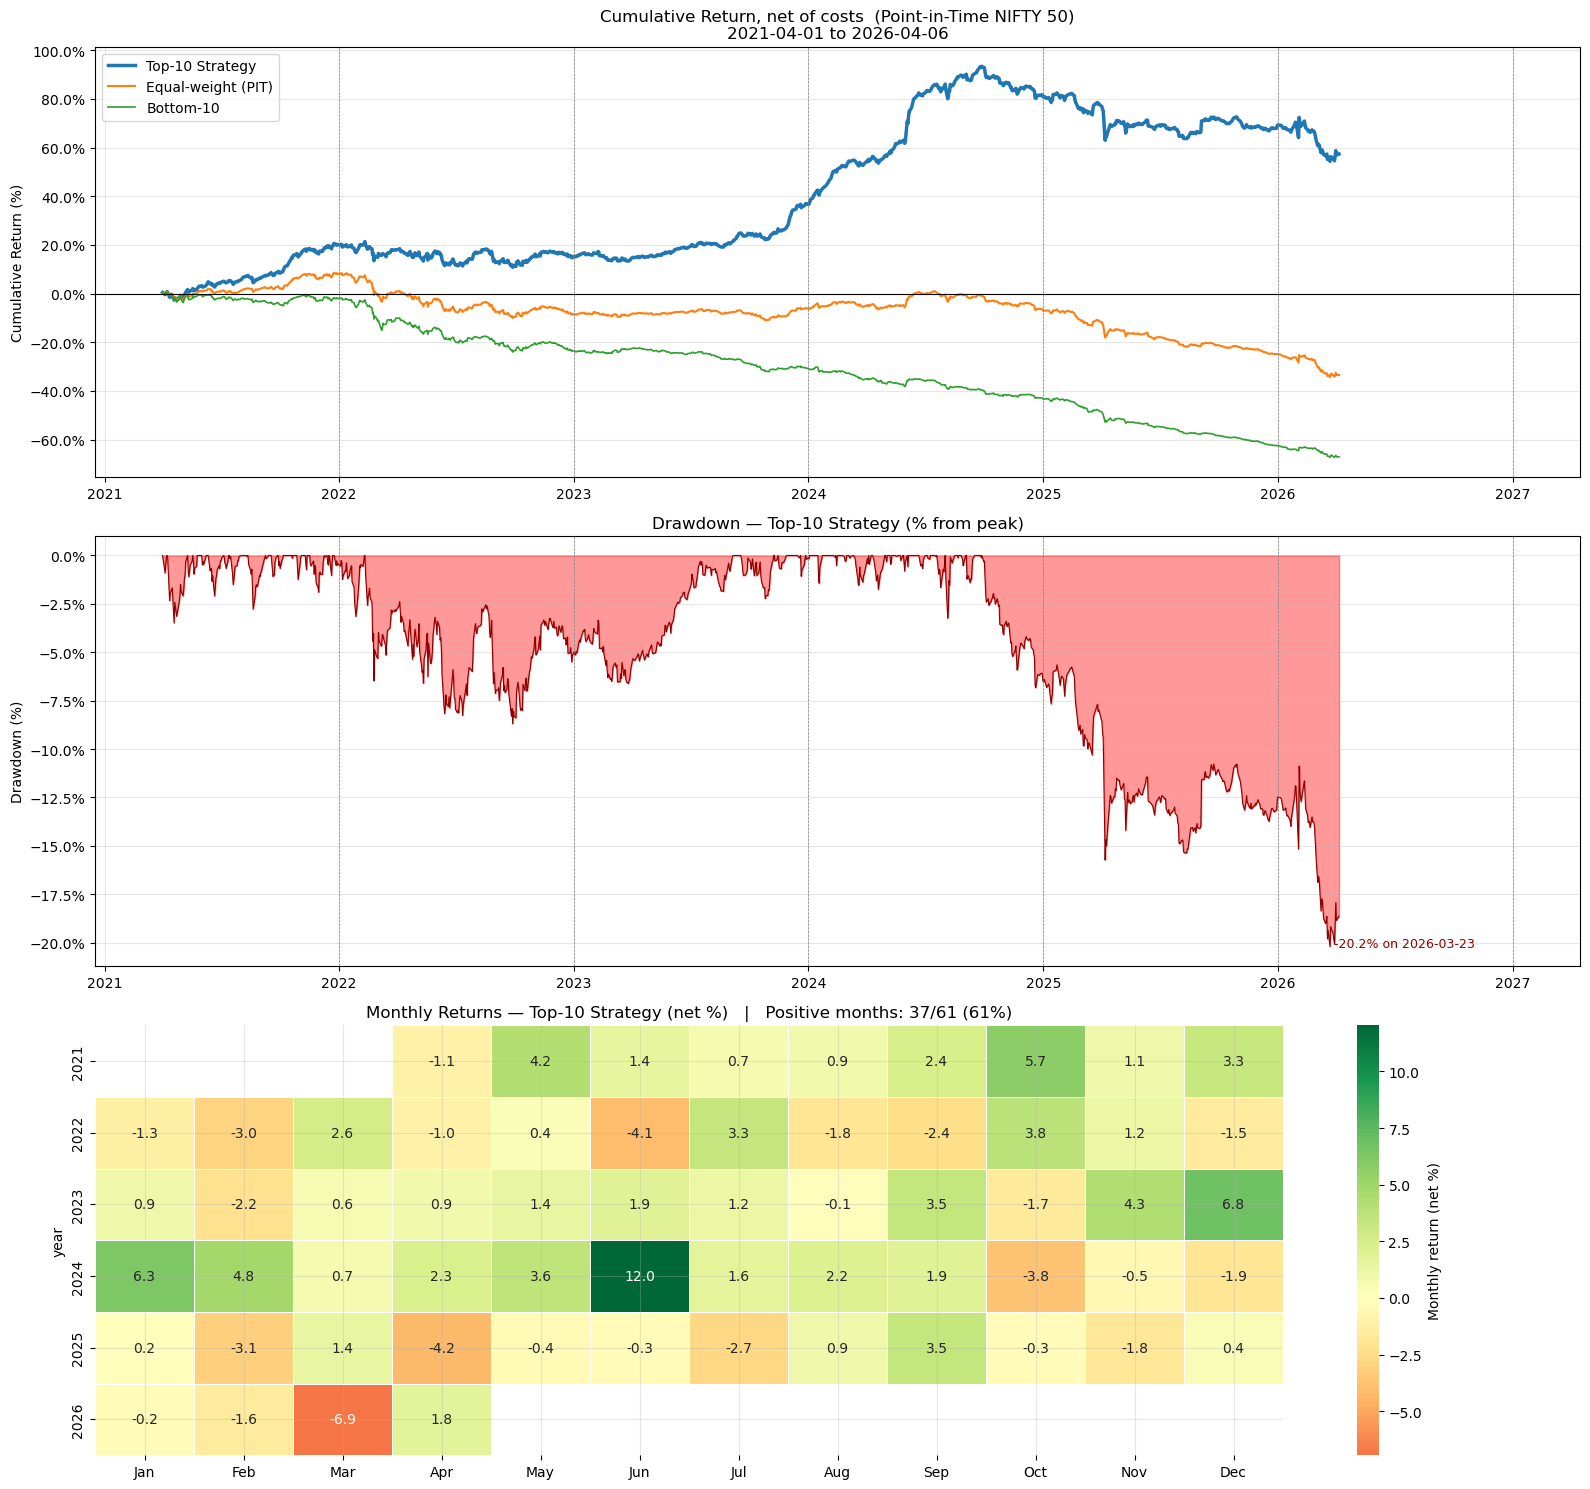

In [ ]:
if len(ret) < 3:
    print(f'Only {len(ret)} session(s) — need at least 3 for charts.')
else:
    n_plots = 2 + (1 if len(ret) >= 20 else 0)
    fig, axes = plt.subplots(n_plots, 1, figsize=(16, 5 * n_plots))
    if n_plots == 2:
        axes = list(axes)

    # ── Cumulative return ──
    ax = axes[0]
    for s, color, lw in [
        (ret,   'darkgreen', 2.5),
        (bench, 'steelblue', 1.5),
        (bot,   'red',       1.2),
    ]:
        cum = (1 + s.dropna()).cumprod() - 1
        ax.plot(cum.index, cum * 100, label=s.name, linewidth=lw)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(
        f'Cumulative Return, net of costs  (Point-in-Time NIFTY 50)\n'
        f'{eff_start.date()} to {eff_end.date()}'
    )
    ax.set_ylabel('Cumulative Return (%)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.legend()
    for yr in range(eff_start.year + 1, eff_end.year + 2):
        ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='grey', linewidth=0.5, linestyle='--')

    # ── Drawdown ──
    ax = axes[1]
    cum = (1 + ret.dropna()).cumprod()
    dd  = (cum / cum.cummax() - 1) * 100
    ax.fill_between(dd.index, dd, 0, color='red', alpha=0.4)
    ax.plot(dd.index, dd, color='darkred', linewidth=0.8)
    ax.set_title('Drawdown — Top-10 Strategy (% from peak)')
    ax.set_ylabel('Drawdown (%)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    worst_dd   = dd.min()
    worst_date = dd.idxmin()
    ax.annotate(
        f' {worst_dd:.1f}% on {worst_date.date()}',
        xy=(worst_date, worst_dd),
        fontsize=9, color='darkred',
    )
    for yr in range(eff_start.year + 1, eff_end.year + 2):
        ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='grey', linewidth=0.5, linestyle='--')

    # ── Monthly heatmap ──
    if len(ret) >= 20:
        ax = axes[2]
        monthly = ret.resample('ME').apply(lambda x: (1 + x).prod() - 1)
        piv = monthly.to_frame('r')
        piv['year']  = piv.index.year
        piv['month'] = piv.index.month
        heat = piv.pivot(index='year', columns='month', values='r')
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        heat.columns = [month_names[m - 1] for m in heat.columns]
        sns.heatmap(
            heat * 100,
            cmap='RdYlGn', center=0,
            annot=True, fmt='.1f',
            linewidths=0.4, ax=ax,
            cbar_kws={'label': 'Monthly return (net %)'}
        )
        pos = (heat > 0).sum().sum()
        tot = heat.notna().sum().sum()
        ax.set_title(
            f'Monthly Returns — Top-10 Strategy (net %)   |   '
            f'Positive months: {pos}/{tot} ({pos / tot:.0%})'
        )

    plt.tight_layout()
    plt.show()

## Constituent Change Log

Shows how many stocks were actually available (in index + had data) on each rebalancing date.

In [ ]:
print('NIFTY 50 Constituent Changes applied in this backtest:')
print(f'  Baseline date:  {BASELINE_DATE.date()} — {len(BASELINE_COMPOSITION)} stocks')
print()
for date_str, added, removed in CHANGE_EVENTS:
    change_dt = pd.Timestamp(date_str)
    if change_dt < pd.Timestamp(START_DATE) or change_dt > pd.Timestamp(END_DATE):
        status = '(outside test range)'
    else:
        status = '(APPLIED)'
    print(f'  {date_str}  {status}')
    print(f'    Added:   {added}')
    print(f'    Removed: {removed}')
    # Check data availability for added stocks
    for sym in added:
        col = resolve_col(sym, set(overnight_df.columns))
        if col in overnight_df.columns:
            first_data = overnight_df[col].first_valid_index()
            print(f'    {sym} ({col}): first data = {first_data.date() if first_data else "none"}')
        else:
            print(f'    {sym}: NOT in data (will be skipped in rankings)')

NIFTY 50 Constituent Changes applied in this backtest:
  Baseline date:  2021-04-01 — 50 stocks

  2022-03-31  (APPLIED)
    Added:   ['APOLLOHOSP']
    Removed: ['IOC']
    APOLLOHOSP (APOLLOHOSP): first data = 2021-02-16
  2022-09-30  (APPLIED)
    Added:   ['ADANIENT']
    Removed: ['SHREECEM']
    ADANIENT (ADANIENT): first data = 2021-02-16
  2023-07-13  (APPLIED)
    Added:   ['LTIM']
    Removed: ['HDFC']
    LTIM (LTIM): first data = 2021-02-16
  2024-03-28  (APPLIED)
    Added:   ['SHRIRAMFIN']
    Removed: ['UPL']
    SHRIRAMFIN (SHRIRAMFIN): first data = 2021-02-16
  2024-09-30  (APPLIED)
    Added:   ['BEL', 'TRENT']
    Removed: ['DIVISLAB', 'LTIM']
    BEL (BEL): first data = 2021-02-16
    TRENT (TRENT): first data = 2021-02-16
  2025-03-28  (APPLIED)
    Added:   ['JIOFIN']
    Removed: ['BPCL']
    JIOFIN (JIOFIN): first data = 2023-08-22
  2025-09-29  (APPLIED)
    Added:   ['ETERNAL', 'INDIGO', 'MAXHEALTH']
    Removed: ['BRITANNIA', 'HEROMOTOCO', 'INDUSINDBK']
    E